# Homework 5

student name:   
`Pradeep Kumar RP`  
`Vamsinath Thatha` 


In [1]:
import numpy as np
import scipy

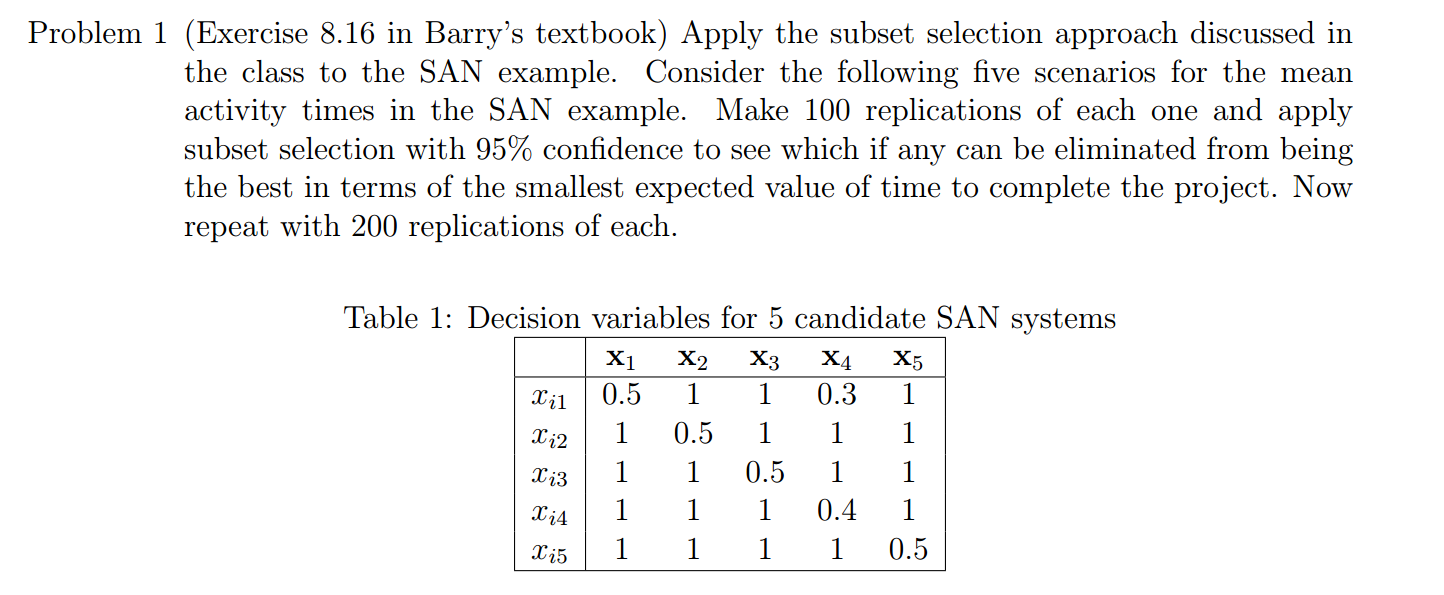

In [37]:
def SAN(x, reps):

    x1, x2, x3, x4, x5 = x
    
    # generate exponential activity times for each replication
    a1 = np.random.exponential(x1, reps)
    a2 = np.random.exponential(x2, reps)
    a3 = np.random.exponential(x3, reps)
    a4 = np.random.exponential(x4, reps)
    a5 = np.random.exponential(x5, reps)

    # project completion time = longest of the 3 paths through the network
    y = np.max([a1+a4, a1+a3+a5, a2+a5], axis=0)
    
    return y


def subset_selection(scenario, reps, alpha=0.05):

    k = len(scenario)
    
    # simulate all K scenarios and compute summary statistics
    data = [SAN(x, reps) for x in scenario]
    mean = [np.mean(d) for d in data]
    var  = [np.var(d, ddof=1) for d in data]

    # critical value: (1-alpha)^(1/(K-1)) quantile of t_{n-1}
    # splits the confidence level across K-1 pairwise comparisons
    # so that the overall guarantee is 1-alpha
    prob  = (1 - alpha) ** (1 / (k - 1))
    tcrit = [scipy.stats.t.ppf(prob, df=reps-1)] * k

    subset = []
    for i in range(k):
        keep = True  # assume scenario i is in the subset until proven otherwise
        
        for h in range(k):
            if h == i: continue  # skip self-comparison
            
            # threshold W_ih accounts for estimation error in both scenarios i and h
            # wider threshold = harder to eliminate = more scenarios retained
            w_ih = np.sqrt(tcrit[i]**2 * var[i]/reps +
                           tcrit[h]**2 * var[h]/reps)
            
            # eliminate scenario i if its mean is significantly worse than scenario h
            # i.e. the difference exceeds the threshold W_ih
            if mean[i] > mean[h] + w_ih:
                keep = False
                break  # no need to check further, already eliminated
            
        # after checking all h, record whether scenario i survived
        if keep:
            subset.append(i+1)  # i+1 to label scenarios 1..K instead of 0..K-1

    print(f"n={reps}: selected scenarios: {subset}")
    print(f"  Means: {[float(round(m, 3)) for m in mean]}")

In [38]:
scenario = [
    [0.5, 1, 1, 0.3, 1],
    [1, 0.5, 1, 1, 1],
    [1, 1, 0.5, 1, 1],
    [1, 1, 1, 0.4, 1],
    [1, 1, 1, 1, 0.5],
]

np.random.seed(12)
subset_selection(scenario, 100)
subset_selection(scenario, 200)

n=100: selected scenarios: [1, 3, 4, 5]
  Means: [2.668, 3.484, 3.013, 3.148, 2.721]
n=200: selected scenarios: [1, 3, 5]
  Means: [2.824, 3.394, 3.112, 3.185, 2.817]


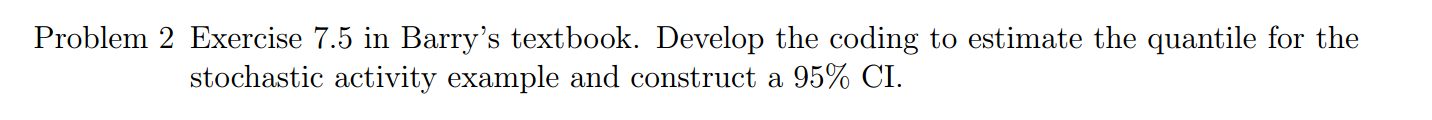

In [40]:
def quantile_CI(x, reps, p=0.9, alpha=0.05):
    
    # simulate and sort the outputs (order statistics)
    y = SAN(x, reps)
    y_sorted = np.sort(y)
    
    # point estimate: ceiling(n*p)-th order statistic
    idx = int(np.ceil(reps * p)) - 1  # -1 for 0-based indexing
    xi_hat = y_sorted[idx]
    
    # CI bounds using binomial distribution
    # l and u are indices into the sorted array
    l = int(scipy.stats.binom.ppf(alpha/2, n=reps, p=p))
    u = int(scipy.stats.binom.ppf(1 - alpha/2, n=reps, p=p))
    
    # clamp to valid index range
    l = max(l, 0)
    u = min(u, reps - 1)
    
    ci_lower = y_sorted[l]
    ci_upper = y_sorted[u]
    
    print(f"Point estimate of {p}-quantile: {xi_hat:.4f}")
    print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    return xi_hat, ci_lower, ci_upper


# use the nominal scenario x = (1,1,1,1,1)
nominal = (1, 1, 1, 1, 1)
np.random.seed(123)
quantile_CI(nominal, reps=1000, p=0.95, alpha=0.05)

Point estimate of 0.95-quantile: 6.7195
95% CI: [6.3427, 7.1452]


(np.float64(6.719523103220314),
 np.float64(6.342725402034339),
 np.float64(7.145176133972395))